# T02 — RUL Computation
**Input:** `data/loaded/train_loaded.csv`, `data/loaded/test_loaded.csv`  
**Goal:** compute Remaining Useful Life for every row; cap at 125 cycles  
**Output:** `data/loaded/train_rul.csv`, `data/loaded/test_rul.csv`  
**Next:** T03_feature_engineering.ipynb

In [ ]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
import pandas as pd
import numpy as np
from src.preprocessing.rul import compute_test_rul, compute_train_rul, verify_test_rul, verify_train_rul

LOADED_DIR = ROOT / "data" / "loaded"

## Load from T01 outputs

In [3]:
train = pd.read_csv(LOADED_DIR / "train_loaded.csv")
test  = pd.read_csv(LOADED_DIR / "test_loaded.csv")
print(f"train: {train.shape}  |  test: {test.shape}")

train: (61249, 26)  |  test: (41214, 27)


## Compute RUL

In [4]:
train.columns

Index(['engine_id', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5',
       's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16',
       's17', 's18', 's19', 's20', 's21'],
      dtype='object')

In [5]:
# train: RUL = max_cycle_per_engine - current_cycle, then cap
train = compute_train_rul(train)

# test: RUL = rul_last + (max_cycle_in_test - current_cycle), then cap
# rul_last column is dropped inside compute_test_rul after use
test = compute_test_rul(test)

## Visualize RUL distributions

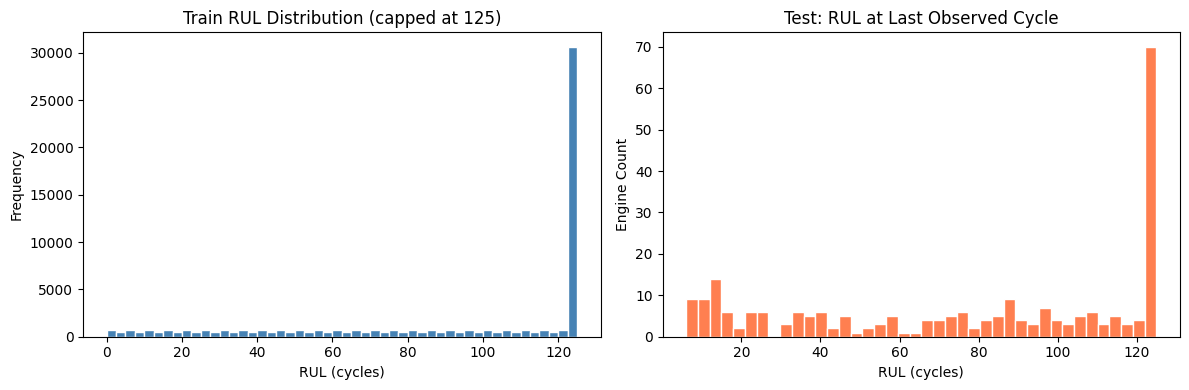

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["RUL"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Train RUL Distribution (capped at 125)")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Frequency")

# last-cycle RUL per test engine using cycle-based idxmax (not positional last)
# BUG FIX: positional last() returns wrong row if DataFrame is not sorted by cycle
last_idx = test.groupby("engine_id")["cycle"].idxmax()
last_test_rul = test.loc[last_idx, "RUL"]
axes[1].hist(last_test_rul, bins=40, color="coral", edgecolor="white")
axes[1].set_title("Test: RUL at Last Observed Cycle")
axes[1].set_xlabel("RUL (cycles)")
axes[1].set_ylabel("Engine Count")

plt.tight_layout()
plt.show()


## Verify

In [7]:
verify_train_rul(train)
verify_test_rul(test)

# rul_last must be removed from test at this point
assert "rul_last" not in test.columns, "rul_last column should have been dropped by compute_test_rul"
print("[PASS] rul_last removed from test")

# confirm RUL column present in both
assert "RUL" in train.columns and "RUL" in test.columns
print("[PASS] RUL column present in both DataFrames")

  [PASS] train RUL: range [0, 125], all engines end at 0
  [PASS] test RUL: range [6, 125]
  [PASS] rul_last absent — no leakage risk
[PASS] rul_last removed from test
[PASS] RUL column present in both DataFrames


## Save

In [8]:
train.to_csv(LOADED_DIR / "train_rul.csv", index=False)
test.to_csv(LOADED_DIR / "test_rul.csv", index=False)
print(f"Saved: {LOADED_DIR / 'train_rul.csv'}")
print(f"Saved: {LOADED_DIR / 'test_rul.csv'}")

Saved: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/data/loaded/train_rul.csv
Saved: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/data/loaded/test_rul.csv
